# 05 - Level 3 Relevance Attribution Workflow

This notebook validates the Level 3 temporal relevance workflow on the same single IEMOCAP utterance used by the previous notebooks, `Ses01F_impro01_F005`.

Level 3 is intentionally shown separately from LeGrad-HuBERT. It is a hybrid rollout method:

```text
level3 = normalize(rollout_score * head_relevance)
```

where `rollout_score` comes from gradient-weighted attention rollout and `head_relevance` comes from the classifier head contribution of each HuBERT time token.

## Setup

The notebook uses the project implementation directly, so the intermediate tensors match the quantitative evaluation code.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.common import MODEL_CLASS_NAMES
from src.explainers.transformer_relevance.attention_extractor import extract_hubert_attentions
from src.explainers.transformer_relevance.gradient_attention import extract_gradient_weighted_attentions
from src.explainers.transformer_relevance.score_pipeline import (
    compute_relevance_scores,
    normalize_token_scores,
)
from src.explainers.transformer_relevance.token_mapping import temporal_relevance_to_dataframe
from src.explainers.transformer_relevance.visualization import (
    plot_relevance_timeline,
    plot_waveform_with_interval_scores,
)
from src.models.load_model import load_hubert_emotion_model
from src.utils.audio import load_audio_mono_16k

TARGET_AUDIO_ID = "Ses01F_impro01_F005"
DEVICE = os.environ.get("NOTEBOOK_DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\mateu\repos\gradient_based_speach_xai
Device: cpu


## Load One Audio And The HuBERT Classifier

The selected example is the same one used by the LeGrad notebook so the two workflows can be compared directly.

In [2]:
metadata = pd.read_csv(PROJECT_ROOT / "data" / "metadata.csv")
example = metadata.loc[metadata["audio_id"].eq(TARGET_AUDIO_ID)].iloc[0]
audio_path = Path(example["audio_path"])
if not audio_path.is_file():
    raise FileNotFoundError(audio_path)

waveform, sampling_rate = load_audio_mono_16k(str(audio_path))
audio_duration = waveform.numel() / sampling_rate
model, processor, device = load_hubert_emotion_model(device=DEVICE, local_files_only=False)

display(pd.DataFrame([{
    "audio_id": TARGET_AUDIO_ID,
    "true_label": example.get("true_label"),
    "audio_path": str(audio_path),
    "sampling_rate": sampling_rate,
    "duration_seconds": audio_duration,
    "waveform_shape": tuple(waveform.shape),
}]))

,audio_id,true_label,audio_path,sampling_rate,duration_seconds,waveform_shape
0,Ses01F_impro01_F005,neu,C:\Users\mateu\repos\gradient_based_speach_xai...,16000,4.029937,"(64479,)"


## Compute Level 3 Relevance

This cell runs the exact project components used by the evaluation pipeline:

1. `extract_hubert_attentions(...)` captures the forward attention maps and the hidden states entering the classifier head.
2. `extract_gradient_weighted_attentions(...)` computes positive `gradient * attention` matrices for the predicted emotion class.
3. `compute_relevance_scores(...)` builds `rollout`, `head_relevance`, and `level3` from those tensors.

In [3]:
base_result = extract_hubert_attentions(
    model=model,
    processor=processor,
    waveform=waveform,
    sampling_rate=sampling_rate,
    device=device,
)
target_class = int(base_result["predicted_class"])

grad_result = extract_gradient_weighted_attentions(
    model=model,
    processor=processor,
    waveform=waveform,
    sampling_rate=sampling_rate,
    device=device,
    target_class=target_class,
)

relevance_result = compute_relevance_scores(
    model=model,
    base_result=base_result,
    grad_result=grad_result,
)

probabilities = torch.softmax(base_result["logits"], dim=-1).squeeze().detach().cpu().numpy()
prediction_table = pd.DataFrame({
    "class_id": list(range(len(MODEL_CLASS_NAMES))),
    "label": MODEL_CLASS_NAMES,
    "logit": base_result["logits"].squeeze().detach().cpu().numpy(),
    "probability": probabilities,
}).sort_values("probability", ascending=False)

display(prediction_table.style.format({"logit": "{:.4f}", "probability": "{:.4f}"}))
display(Markdown(f"**Target explained class:** `{MODEL_CLASS_NAMES[target_class]}` (`class_id={target_class}`)."))

,class_id,label,logit,probability
2,2,ang,1.1024,0.5195
1,1,hap,0.7522,0.3660
0,0,neu,-0.6679,0.0885
3,3,sad,-1.8942,0.0260


**Target explained class:** `ang` (`class_id=2`).

## Intermediate Shape Checks

These shapes verify that the Level 3 workflow is using attention-layer tensors, token-level rollout scores, and token-level head relevance with compatible dimensions.

In [4]:
scores = relevance_result["scores"]
rollout_score = scores["rollout"]
head_relevance = relevance_result["head_relevance"]
level3_score = scores["level3"]
manual_level3 = normalize_token_scores(rollout_score * head_relevance)

shape_rows = [
    {
        "object": "base_result['attentions']",
        "shape": f"{len(base_result['attentions'])} layers x {tuple(base_result['attentions'][0].shape)}",
        "meaning": "forward HuBERT attention probabilities [batch, heads, query_tokens, source_tokens]",
    },
    {
        "object": "grad_result['attention_grads']",
        "shape": f"{len(grad_result['attention_grads'])} layers x {tuple(grad_result['attention_grads'][0].shape)}",
        "meaning": "gradient of the target emotion logit with respect to each attention map",
    },
    {
        "object": "grad_result['grad_attentions']",
        "shape": f"{len(grad_result['grad_attentions'])} layers x {tuple(grad_result['grad_attentions'][0].shape)}",
        "meaning": "mean over heads of ReLU(gradient * attention), one matrix per Transformer layer",
    },
    {
        "object": "relevance_result['joint_attention']",
        "shape": tuple(relevance_result["joint_attention"].shape),
        "meaning": "residual-added, row-normalized gradient-weighted attention matrices multiplied across layers",
    },
    {
        "object": "relevance_result['raw_rollout']",
        "shape": tuple(relevance_result["raw_rollout"].shape),
        "meaning": "mean over query tokens of the joint rollout matrix, min-max normalized by rollout_to_temporal_relevance",
    },
    {
        "object": "scores['rollout']",
        "shape": tuple(rollout_score.shape),
        "meaning": "sum-normalized rollout temporal score",
    },
    {
        "object": "relevance_result['head_relevance']",
        "shape": tuple(head_relevance.shape),
        "meaning": "sum-normalized token contribution through projector, mean pooling, and classifier",
    },
    {
        "object": "scores['level3']",
        "shape": tuple(level3_score.shape),
        "meaning": "sum-normalized product of rollout_score and head_relevance",
    },
]
shape_table = pd.DataFrame(shape_rows)
display(shape_table)
display(Markdown("**Legend.** `object` is the tensor or list returned by the code; `shape` gives its dimensionality; `meaning` explains its role in the Level 3 construction."))
print("max |manual_level3 - scores['level3']| =", float((manual_level3 - level3_score).abs().max().detach().cpu()))

,object,shape,meaning
0,base_result['attentions'],"12 layers x (1, 12, 201, 201)","forward HuBERT attention probabilities [batch,..."
1,grad_result['attention_grads'],"12 layers x (1, 12, 201, 201)",gradient of the target emotion logit with resp...
2,grad_result['grad_attentions'],"12 layers x (1, 201, 201)","mean over heads of ReLU(gradient * attention),..."
3,relevance_result['joint_attention'],"(1, 201, 201)","residual-added, row-normalized gradient-weight..."
4,relevance_result['raw_rollout'],"(1, 201)",mean over query tokens of the joint rollout ma...
5,scores['rollout'],"(1, 201)",sum-normalized rollout temporal score
6,relevance_result['head_relevance'],"(1, 201)",sum-normalized token contribution through proj...
7,scores['level3'],"(1, 201)",sum-normalized product of rollout_score and he...


**Legend.** `object` is the tensor or list returned by the code; `shape` gives its dimensionality; `meaning` explains its role in the Level 3 construction.

max |manual_level3 - scores['level3']| = 0.0


## How The Layer Attention Matrices Are Built

For Level 3, each layer matrix is not the raw attention matrix. It is built from the target-class gradient and the attention probabilities:

```text
grad_attn_l = mean_heads(ReLU((d score_target / d attention_l) * attention_l))
```

Those layer matrices are then passed to attention rollout.

In [5]:
layer_rows = []
for layer_index, (attention, gradient, grad_attention) in enumerate(
    zip(base_result["attentions"], grad_result["attention_grads"], grad_result["grad_attentions"]),
    start=1,
):
    layer_rows.append({
        "layer": layer_index,
        "attention_shape": tuple(attention.shape),
        "gradient_shape": tuple(gradient.shape),
        "layer_matrix_shape": tuple(grad_attention.shape),
        "layer_matrix_min": float(grad_attention.min().detach().cpu()),
        "layer_matrix_max": float(grad_attention.max().detach().cpu()),
        "layer_matrix_sum": float(grad_attention.sum().detach().cpu()),
        "mean_row_sum_before_residual": float(grad_attention.sum(dim=-1).mean().detach().cpu()),
    })
layer_table = pd.DataFrame(layer_rows)
display(layer_table.style.format({
    "layer_matrix_min": "{:.6g}",
    "layer_matrix_max": "{:.6g}",
    "layer_matrix_sum": "{:.6g}",
    "mean_row_sum_before_residual": "{:.6g}",
}))
display(Markdown("**Legend.** `layer_matrix_shape` is the matrix sent to rollout after positive gradient-times-attention and head averaging. Residual addition and row normalization happen later inside `compute_rollout_attention`."))

,layer,attention_shape,gradient_shape,layer_matrix_shape,layer_matrix_min,layer_matrix_max,layer_matrix_sum,mean_row_sum_before_residual
0,1,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000871071,0.75602,0.0037613
1,2,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000905344,0.654524,0.00325634
2,3,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",1.10244e-07,0.00122051,0.613239,0.00305094
3,4,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",4.42757e-11,0.00113984,0.544816,0.00271053
4,5,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000740332,0.408702,0.00203334
5,6,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000541114,0.35485,0.00176542
6,7,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000386686,0.282514,0.00140554
7,8,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000195818,0.225985,0.0011243
8,9,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",0,0.000231404,0.163845,0.000815152
9,10,"(1, 12, 201, 201)","(1, 12, 201, 201)","(1, 201, 201)",1.86983e-09,0.000125439,0.119351,0.000593787


**Legend.** `layer_matrix_shape` is the matrix sent to rollout after positive gradient-times-attention and head averaging. Residual addition and row normalization happen later inside `compute_rollout_attention`.

## Formula Workflow

The table below maps the implemented steps to the variables inspected in this notebook.

In [6]:
workflow_steps = pd.DataFrame([
    {
        "step": 1,
        "name": "target score",
        "implemented as": "score_target = logits[:, predicted_class].sum()",
        "output": "scalar emotion score used for backpropagation",
    },
    {
        "step": 2,
        "name": "gradient-weighted layer matrix",
        "implemented as": "grad_attn_l = mean_heads(ReLU((d score_target / d A_l) * A_l))",
        "output": "grad_result['grad_attentions'][l] with shape [batch, tokens, tokens]",
    },
    {
        "step": 3,
        "name": "attention rollout",
        "implemented as": "joint_attention = product_l(row_normalize(grad_attn_l + I))",
        "output": "relevance_result['joint_attention']",
    },
    {
        "step": 4,
        "name": "rollout temporal score",
        "implemented as": "raw_rollout = minmax(mean_query(joint_attention)); rollout_score = sum_normalize(raw_rollout)",
        "output": "scores['rollout']",
    },
    {
        "step": 5,
        "name": "classifier-head token relevance",
        "implemented as": "head_relevance = positive token contribution through projector -> mean pooling -> classifier",
        "output": "relevance_result['head_relevance']",
    },
    {
        "step": 6,
        "name": "Level 3 product",
        "implemented as": "level3 = sum_normalize(rollout_score * head_relevance)",
        "output": "scores['level3']",
    },
])
display(workflow_steps)
display(Markdown("**Legend.** `A_l` is the layer attention tensor. Level 3 uses rollout and head relevance together; it is therefore different from the LeGrad-HuBERT modes, which use positive attention gradients directly and do not use rollout."))

,step,name,implemented as,output
0,1,target score,"score_target = logits[:, predicted_class].sum()",scalar emotion score used for backpropagation
1,2,gradient-weighted layer matrix,grad_attn_l = mean_heads(ReLU((d score_target ...,grad_result['grad_attentions'][l] with shape [...
2,3,attention rollout,joint_attention = product_l(row_normalize(grad...,relevance_result['joint_attention']
3,4,rollout temporal score,raw_rollout = minmax(mean_query(joint_attentio...,scores['rollout']
4,5,classifier-head token relevance,head_relevance = positive token contribution t...,relevance_result['head_relevance']
5,6,Level 3 product,level3 = sum_normalize(rollout_score * head_re...,scores['level3']


**Legend.** `A_l` is the layer attention tensor. Level 3 uses rollout and head relevance together; it is therefore different from the LeGrad-HuBERT modes, which use positive attention gradients directly and do not use rollout.

## Top Temporal Tokens

This table shows how the final Level 3 score changes when the rollout score and head relevance are multiplied.

In [7]:
level3_df = temporal_relevance_to_dataframe(level3_score, audio_duration)
rollout_df = temporal_relevance_to_dataframe(rollout_score, audio_duration).rename(columns={"relevance": "rollout_score"})
head_df = temporal_relevance_to_dataframe(head_relevance, audio_duration).rename(columns={"relevance": "head_relevance"})
level3_df = level3_df.rename(columns={"relevance": "level3_score"})
workflow_df = level3_df.merge(
    rollout_df[["token_idx", "rollout_score"]], on="token_idx", how="left"
).merge(
    head_df[["token_idx", "head_relevance"]], on="token_idx", how="left"
)
workflow_df["product_before_normalization"] = workflow_df["rollout_score"] * workflow_df["head_relevance"]
score_min = workflow_df["level3_score"].min()
score_max = workflow_df["level3_score"].max()
workflow_df["level3_visual_minmax"] = (
    (workflow_df["level3_score"] - score_min) / max(score_max - score_min, np.finfo(float).eps)
)

top_tokens = workflow_df.sort_values("level3_score", ascending=False).head(12).copy()
display(top_tokens[[
    "token_idx", "start_time", "end_time", "rollout_score", "head_relevance",
    "product_before_normalization", "level3_score", "level3_visual_minmax",
]].style.format({
    "start_time": "{:.3f}",
    "end_time": "{:.3f}",
    "rollout_score": "{:.6f}",
    "head_relevance": "{:.6f}",
    "product_before_normalization": "{:.8f}",
    "level3_score": "{:.6f}",
    "level3_visual_minmax": "{:.3f}",
}))
display(Markdown("**Legend.** `rollout_score` is the temporal score from gradient-weighted attention flow; `head_relevance` is the classifier-head contribution; `level3_score` is their normalized product. `level3_visual_minmax` is only for plotting contrast."))

,token_idx,start_time,end_time,rollout_score,head_relevance,product_before_normalization,level3_score,level3_visual_minmax
136,136,2.727,2.747,0.007518,0.022002,0.00016541,0.032497,1.000
137,137,2.747,2.767,0.006503,0.021122,0.00013736,0.026986,0.830
134,134,2.687,2.707,0.006522,0.019826,0.00012931,0.025405,0.782
135,135,2.707,2.727,0.006123,0.019766,0.00012102,0.023776,0.732
131,131,2.626,2.647,0.006999,0.016570,0.00011598,0.022785,0.701
1,1,0.020,0.040,0.007115,0.016289,0.00011590,0.022770,0.701
0,0,0.000,0.020,0.007013,0.016424,0.00011519,0.022630,0.696
3,3,0.060,0.080,0.006331,0.017914,0.00011341,0.022281,0.686
85,85,1.704,1.724,0.005550,0.019075,0.00010587,0.020801,0.640
2,2,0.040,0.060,0.005877,0.017777,0.00010447,0.020525,0.632


**Legend.** `rollout_score` is the temporal score from gradient-weighted attention flow; `head_relevance` is the classifier-head contribution; `level3_score` is their normalized product. `level3_visual_minmax` is only for plotting contrast.

## Notebook-01-Style Visualization

The first plot uses the reusable spectrogram-plus-token-relevance view. The second plot uses the waveform interval-score view from Notebook 01.

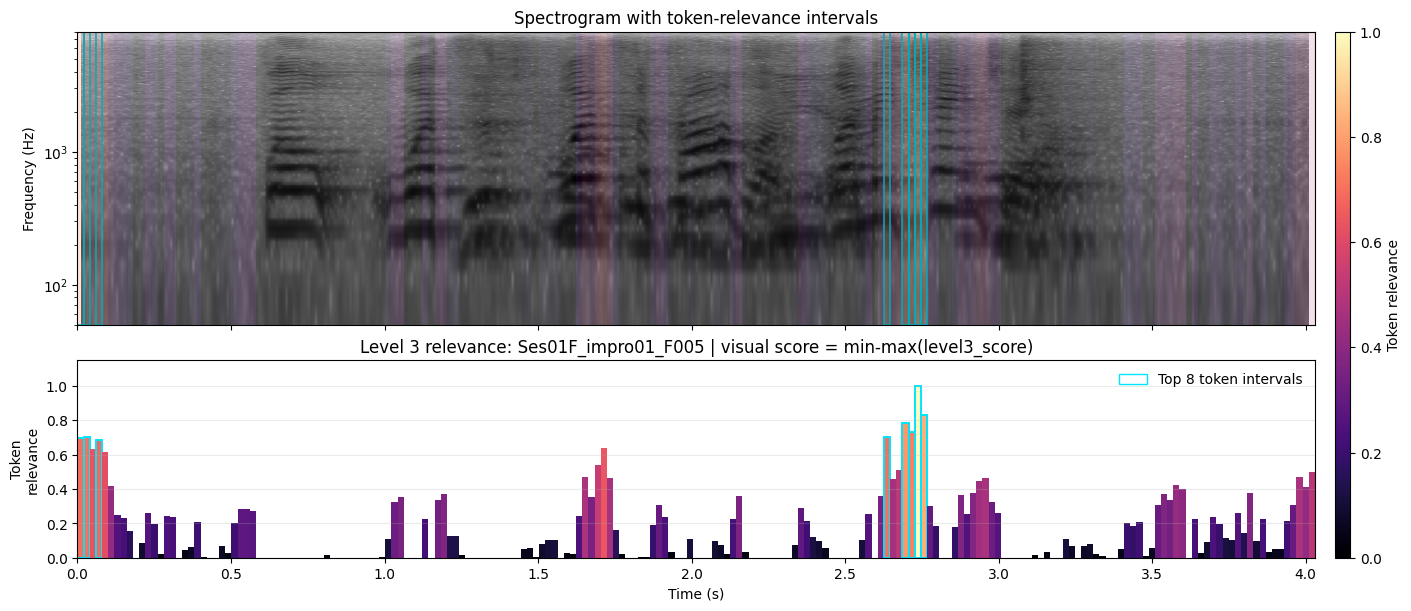

C:\Users\mateu\repos\gradient_based_speach_xai\src\explainers\transformer_relevance\visualization.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=[0, 0, 1, 0.93])


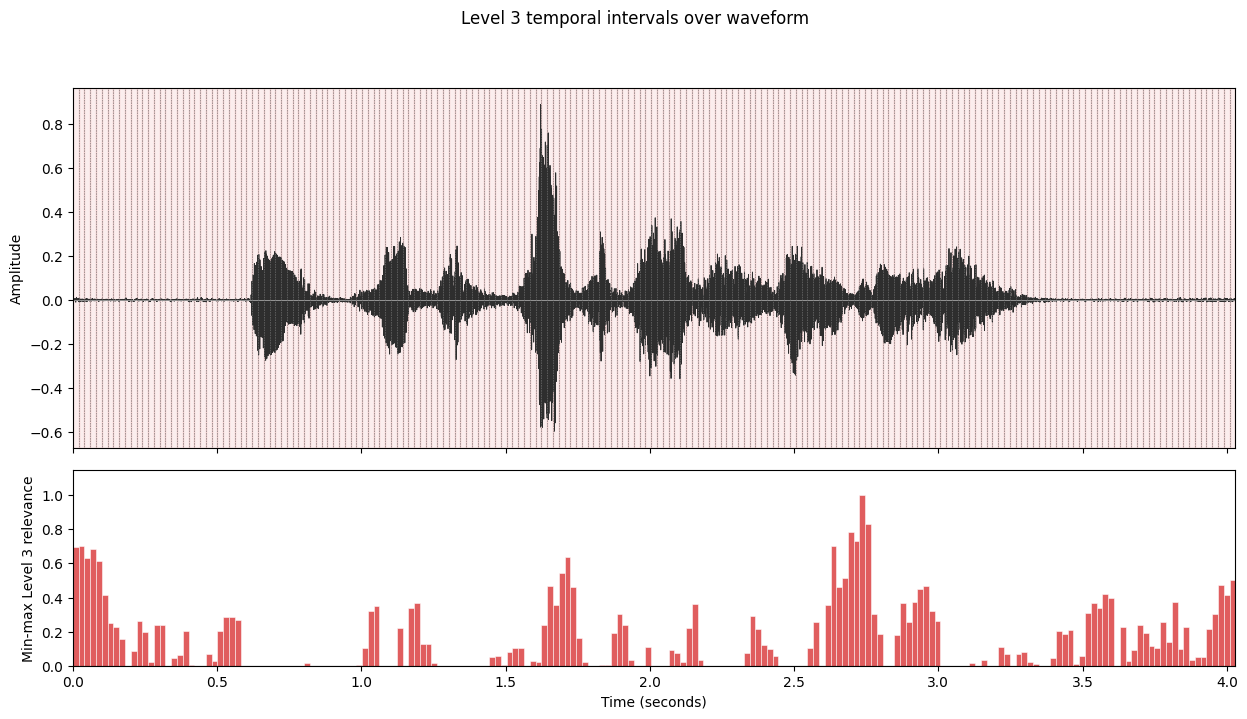

In [8]:
plot_df = workflow_df[["token_idx", "start_time", "end_time", "level3_visual_minmax"]].rename(
    columns={"level3_visual_minmax": "relevance"}
)
plot_relevance_timeline(
    waveform,
    sampling_rate,
    plot_df,
    relevance_title=(
        f"Level 3 relevance: {TARGET_AUDIO_ID} | "
        "visual score = min-max(level3_score)"
    ),
    top_k=8,
)

plot_waveform_with_interval_scores(
    waveform,
    sampling_rate,
    plot_df,
    title="Level 3 temporal intervals over waveform",
    score_label="Min-max Level 3 relevance",
    positive_color="tab:red",
)

## Result

This notebook validates the Level 3 attribution workflow for one real HuBERT emotion-classification example. The important distinction is that Level 3 combines two signals: gradient-weighted attention rollout and classifier-head token relevance. LeGrad-HuBERT, shown in Notebook 04, is kept separate because its score is based on positive attention gradients rather than rollout.